This code implements the Swin Transformer: Hierarchical Vision Transformer using Shifted Windows for image classification and demonstrates its application on the BTXRD dataset.

The Swin Transformer, short for Shifted Window Transformer, is a general-purpose vision backbone designed for efficient and scalable computer vision tasks. Unlike standard Vision Transformers that compute global self-attention across the entire image, the Swin Transformer computes self-attention within local non-overlapping windows. By introducing a shifted window mechanism, the model enables information exchange across neighboring windows while maintaining computational efficiency. This design allows the architecture to capture both local and hierarchical image features at multiple scales, with computational complexity growing linearly with image size.


In this implementation, Inception-ResNet-v2 is used as the backbone feature extractor to obtain rich spatial and semantic representations from input X-ray images. These extracted feature maps are then passed into the Swin Transformer module, where shifted-window self-attention further enhances feature learning by modeling contextual relationships across image regions. The combination of Inception-ResNet-v2 and Swin Transformer provides a strong hybrid framework for improving image classification performance, particularly in medical and X-ray image analysis tasks.

## Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf  # For tf.data and preprocessing only.
import keras
from keras import layers
from keras import ops

## Configure the hyperparameters

A key parameter to pick is the `patch_size`, the size of the input patches.
In order to use each pixel as an individual input, you can set `patch_size` to
`(1, 1)`. Below, we take inspiration from the original paper settings for
training on ImageNet-1K, keeping most of the original settings for this example.

In [ ]:

IMG_SIZE = 299
input_shape = (IMG_SIZE, IMG_SIZE, 1)

patch_size = (1, 1)
dropout_rate = 0.1
num_heads = 4
embed_dim = 96
num_mlp = 256
qkv_bias = True

window_size = (5, 5)     # must be tuple
shift_size  = (0, 0)     # start stable; later try (3,3)

num_patch_x = IMG_SIZE // patch_size[0]   # 74
num_patch_y = IMG_SIZE // patch_size[1]   # 74

learning_rate = 1e-4
BATCH_SIZE = 8
num_epochs = 3000
weight_decay = 1e-5
label_smoothing = 0.0

In [ ]:
import os
import json
import numpy as np
import tensorflow as tf

train_dir = "/content/drive/MyDrive/LYTIC LESION/TRAIN/"
val_dir   = "/content/drive/MyDrive/LYTIC LESION/VAL/"
test_dir  = "/content/drive/MyDrive/LYTIC LESION/TEST/"


JSON_NAME = None
IMG_EXTS = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")

# ------------------------------------------------------------
# 1) Helper functions
# ------------------------------------------------------------
def find_all_json_files(folder):
    json_files = []
    for root, _, files in os.walk(folder):
        for fn in files:
            if fn.startswith("."):
                continue
            if fn.lower().endswith(".json"):
                if JSON_NAME is None or fn == JSON_NAME:
                    json_files.append(os.path.join(root, fn))
    return json_files


def build_bbox_map(split_root):
    """
    Returns:
        bbox_map = { image_basename: np.array([x,y,w,h], dtype=float32) normalized }
    """
    bbox_map = {}

    for root, _, files in os.walk(split_root):
        for fn in files:
            if fn.startswith("."):
                continue
            if not fn.lower().endswith(".json"):
                continue

            coco_path = os.path.join(root, fn)

            with open(coco_path, "r") as f:
                coco = json.load(f)

            img_id_to_info = {im["id"]: im for im in coco.get("images", [])}

            for ann in coco.get("annotations", []):
                img_id = ann.get("image_id")
                im = img_id_to_info.get(img_id)

                if im is None:
                    continue

                file_name = os.path.basename(im.get("file_name", ""))
                bbox = ann.get("bbox", None)
                W = im.get("width", None)
                H = im.get("height", None)

                if not file_name or bbox is None or W is None or H is None:
                    continue

                if not isinstance(bbox, (list, tuple)) or len(bbox) != 4:
                    print(f"Skipping malformed bbox in {coco_path} for {file_name}: {bbox}")
                    continue

                x, y, w, h = bbox
                bbox_norm = np.array(
                    [float(x)/float(W), float(y)/float(H), float(w)/float(W), float(h)/float(H)],
                    dtype=np.float32
                )

                bbox_map[file_name] = bbox_norm

    return bbox_map


train_bbox_map = build_bbox_map(train_dir)
val_bbox_map   = build_bbox_map(val_dir)
test_bbox_map  = build_bbox_map(test_dir)

print("Train bbox entries:", len(train_bbox_map))
print("Val bbox entries:", len(val_bbox_map))
print("Test bbox entries:", len(test_bbox_map))


# ------------------------------------------------------------
# 2) Collect image paths + bboxes
# ------------------------------------------------------------
def collect_samples(split_root, bbox_map):
    paths = []
    bboxes = []

    for root, _, files in os.walk(split_root):
        for fn in files:
            if fn.startswith("."):
                continue
            if not fn.lower().endswith(IMG_EXTS):
                continue

            full_path = os.path.join(root, fn)

            if fn not in bbox_map:
                print(f"Skipping image with no bbox: {full_path}")
                continue

            paths.append(full_path)
            bboxes.append(bbox_map[fn])

    paths = np.array(paths)
    bboxes = np.array(bboxes, dtype=np.float32)

    print(f"{split_root} -> kept {len(paths)} images with bboxes")
    print("bbox array shape:", bboxes.shape)

    return paths, bboxes


# ------------------------------------------------------------
# 3) Robust image loader
# ------------------------------------------------------------
def decode_and_resize(path):
    img_bytes = tf.io.read_file(path)

    # Decode using file extension so the output shape is known
    path_lower = tf.strings.lower(path)

    def decode_png():
        img = tf.image.decode_png(img_bytes, channels=1) # Changed channels to 1
        img.set_shape([None, None, 1])
        return img

    def decode_jpg():
        img = tf.image.decode_jpeg(img_bytes, channels=1) # Changed channels to 1
        img.set_shape([None, None, 1])
        return img

    def decode_bmp():
        # BMP decoding defaults to 3 channels, convert to grayscale (1 channel)
        img = tf.image.decode_bmp(img_bytes)
        if img.shape[-1] == 3:
            img = tf.image.rgb_to_grayscale(img)
        img.set_shape([None, None, 1])
        return img

    # tif/tiff are not supported by tf.image decode functions directly
    # so keep only png/jpg/jpeg/bmp in practice unless you convert tif first
    img = tf.case(
        [
            (tf.strings.regex_full_match(path_lower, ".*\\.png"), decode_png),
            (tf.strings.regex_full_match(path_lower, ".*\\.jpg"), decode_jpg),
            (tf.strings.regex_full_match(path_lower, ".*\\.jpeg"), decode_jpg),
            (tf.strings.regex_full_match(path_lower, ".*\\.bmp"), decode_bmp),
        ],
        default=decode_jpg,
        exclusive=True
    )

    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0
    img.set_shape([IMG_SIZE, IMG_SIZE, 1])

    return img


# ------------------------------------------------------------
# 4) Dataset creation
# ------------------------------------------------------------
def make_detector_ds(split_root, bbox_map, shuffle, batch_size):
    paths, bboxes = collect_samples(split_root, bbox_map)

    ds = tf.data.Dataset.from_tensor_slices((paths, bboxes))

    if shuffle and len(paths) > 0:
        ds = ds.shuffle(len(paths), reshuffle_each_iteration=True)

    def _load(path, bbox):
        img = decode_and_resize(path)
        bbox = tf.cast(bbox, tf.float32)
        bbox = tf.ensure_shape(bbox, [4])
        return img, bbox

    ds = ds.map(_load, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = make_detector_ds(train_dir, train_bbox_map, True, BATCH_SIZE)
val_ds   = make_detector_ds(val_dir, val_bbox_map, False, BATCH_SIZE)
test_ds  = make_detector_ds(test_dir, test_bbox_map, False, BATCH_SIZE)

# Quick check
for images, boxes in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Boxes shape :", boxes.shape)
    print("First bbox  :", boxes[0].numpy())

Train bbox entries: 60
Val bbox entries: 30
Test bbox entries: 10
/content/drive/MyDrive/LYTIC LESION/TRAIN/ -> kept 60 images with bboxes
bbox array shape: (60, 4)
/content/drive/MyDrive/LYTIC LESION/VAL/ -> kept 30 images with bboxes
bbox array shape: (30, 4)
/content/drive/MyDrive/LYTIC LESION/TEST/ -> kept 10 images with bboxes
bbox array shape: (10, 4)
Images shape: (8, 299, 299, 1)
Boxes shape : (8, 4)
First bbox  : [0.37774226 0.1984127  0.12654747 0.11243387]


## Helper functions

We create two helper functions to help us get a sequence of
patches from the image, merge patches, and apply dropout.

In [ ]:
import tensorflow as tf

def window_partition(x, window_size):
    # x: (B, H, W, C)
    ws_h, ws_w = window_size  # window_size must be tuple like (7,7)

    shape = tf.shape(x)
    B, H, W, C = shape[0], shape[1], shape[2], shape[3]

    pad_h = (ws_h - (H % ws_h)) % ws_h
    pad_w = (ws_w - (W % ws_w)) % ws_w

    x = tf.pad(x, [[0,0], [0,pad_h], [0,pad_w], [0,0]])
    Hp = H + pad_h
    Wp = W + pad_w

    x = tf.reshape(
        x,
        (B, Hp // ws_h, ws_h, Wp // ws_w, ws_w, C)
    )
    x = tf.transpose(x, (0, 1, 3, 2, 4, 5))  # (B, num_h, num_w, ws_h, ws_w, C)
    windows = tf.reshape(x, (-1, ws_h, ws_w, C))  # (B*num_windows, ws_h, ws_w, C)

    # Return original H,W too so reverse can slice cleanly
    return windows, (Hp, Wp), (H, W)


def window_reverse(windows, window_size, Hp, Wp, H, W, C):
    ws_h, ws_w = window_size

    num_h = Hp // ws_h
    num_w = Wp // ws_w
    B = tf.shape(windows)[0] // (num_h * num_w)

    x = tf.reshape(windows, (B, num_h, num_w, ws_h, ws_w, C))
    x = tf.transpose(x, (0, 1, 3, 2, 4, 5))   # (B, num_h, ws_h, num_w, ws_w, C)
    x = tf.reshape(x, (B, Hp, Wp, C))

    # remove padding safely by slicing to original H,W
    x = x[:, :H, :W, :]
    return x

## Window based multi-head self-attention

Usually Transformers perform global self-attention, where the relationships
between a token and all other tokens are computed. The global computation leads
to quadratic complexity with respect to the number of tokens. Here, as the
[original paper](https://arxiv.org/abs/2103.14030) suggests, we compute
self-attention within local windows, in a non-overlapping manner. Global
self-attention leads to quadratic computational complexity in the number of
patches, whereas window-based self-attention leads to linear complexity and is
easily scalable.

In [ ]:
class WindowAttention(layers.Layer):
    def __init__(
        self,
        dim,
        window_size,
        num_heads,
        qkv_bias=True,
        dropout_rate=0.0,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.dim = dim
        self.window_size = window_size
        self.num_heads = num_heads
        self.scale = (dim // num_heads) ** -0.5

        self.qkv = layers.Dense(dim * 3, use_bias=qkv_bias)
        self.dropout = layers.Dropout(dropout_rate)
        self.proj = layers.Dense(dim)

        num_window_elements = (
            (2 * self.window_size[0] - 1)
            * (2 * self.window_size[1] - 1)
        )

        self.relative_position_bias_table = self.add_weight(
            shape=(num_window_elements, self.num_heads),
            initializer=keras.initializers.Zeros(),
            trainable=True,
        )

        coords_h = np.arange(self.window_size[0])
        coords_w = np.arange(self.window_size[1])
        coords_matrix = np.meshgrid(coords_h, coords_w, indexing="ij")
        coords = np.stack(coords_matrix)
        coords_flatten = coords.reshape(2, -1)

        relative_coords = coords_flatten[:, :, None] - coords_flatten[:, None, :]
        relative_coords = relative_coords.transpose([1, 2, 0])

        relative_coords[:, :, 0] += self.window_size[0] - 1
        relative_coords[:, :, 1] += self.window_size[1] - 1
        relative_coords[:, :, 0] *= 2 * self.window_size[1] - 1

        relative_position_index = relative_coords.sum(-1)

        self.relative_position_index = keras.Variable(
            initializer=relative_position_index,
            shape=relative_position_index.shape,
            dtype="int",
            trainable=False,
        )

    def call(self, x, mask=None):
        shape = ops.shape(x)
        size = shape[1]
        channels = x.shape[-1]
        head_dim = channels // self.num_heads

        x_qkv = self.qkv(x)
        x_qkv = ops.reshape(x_qkv, (-1, size, 3, self.num_heads, head_dim))
        x_qkv = ops.transpose(x_qkv, (2, 0, 3, 1, 4))
        q, k, v = x_qkv[0], x_qkv[1], x_qkv[2]

        q = q * self.scale
        k = ops.transpose(k, (0, 1, 3, 2))
        attn = q @ k

        num_window_elements = (
            self.window_size[0] * self.window_size[1]
        )

        relative_position_index_flat = ops.reshape(
            self.relative_position_index, (-1,)
        )

        relative_position_bias = ops.take(
            self.relative_position_bias_table,
            relative_position_index_flat,
            axis=0,
        )

        relative_position_bias = ops.reshape(
            relative_position_bias,
            (num_window_elements, num_window_elements, -1),
        )

        relative_position_bias = ops.transpose(
            relative_position_bias, (2, 0, 1)
        )

        attn = attn + ops.expand_dims(relative_position_bias, axis=0)

        if mask is not None:
            nW = ops.shape(mask)[0]

            mask_float = ops.cast(
                ops.expand_dims(
                    ops.expand_dims(mask, axis=1), axis=0
                ),
                "float32",
            )

            attn = ops.reshape(
                attn,
                (-1, nW, self.num_heads, size, size),
            ) + mask_float

            attn = ops.reshape(
                attn,
                (-1, self.num_heads, size, size),
            )

        attn = keras.activations.softmax(attn, axis=-1)
        attn = self.dropout(attn)

        x_out = attn @ v
        x_out = ops.transpose(x_out, (0, 2, 1, 3))
        x_out = ops.reshape(x_out, (-1, size, channels))

        x_out = self.proj(x_out)
        x_out = self.dropout(x_out)

        return x_out

## The complete Swin Transformer model

Finally, we put together the complete Swin Transformer by replacing the standard
multi-head attention (MHA) with shifted windows attention. As suggested in the
original paper, we create a model comprising of a shifted window-based MHA
layer, followed by a 2-layer MLP with GELU nonlinearity in between, applying
`LayerNormalization` before each MSA layer and each MLP, and a residual
connection after each of these layers.

Notice that we only create a simple MLP with 2 Dense and
2 Dropout layers. Often you will see models using ResNet-50 as the MLP which is
quite standard in the literature. However in this paper the authors use a
2-layer MLP with GELU nonlinearity in between.

In [ ]:
class SwinTransformer(layers.Layer):
    def __init__(
        self,
        dim,
        num_patch,              # (H, W) patch grid
        num_heads,
        window_size=(5, 5),
        shift_size=(0, 0),
        num_mlp=1024,
        qkv_bias=True,
        dropout_rate=0.0,
        **kwargs,
    ):
        super().__init__(**kwargs)

        self.dim = dim
        self.num_patch = num_patch          # (H, W)
        self.num_heads = num_heads
        self.window_size = window_size      # (ws_h, ws_w)
        self.shift_size = shift_size        # (sh_h, sh_w)
        self.num_mlp = num_mlp

        self.norm1 = layers.LayerNormalization(epsilon=1e-5)
        self.attn = WindowAttention(
            dim=dim,
            window_size=self.window_size,
            num_heads=num_heads,
            qkv_bias=qkv_bias,
            dropout_rate=dropout_rate,
        )

        self.drop_path = layers.Dropout(dropout_rate)
        self.norm2 = layers.LayerNormalization(epsilon=1e-5)

        self.mlp = keras.Sequential(
            [
                layers.Dense(num_mlp),
                layers.Activation(keras.activations.gelu),
                layers.Dropout(dropout_rate),
                layers.Dense(dim),
                layers.Dropout(dropout_rate),
            ]
        )

        # If feature map smaller than window, clamp window + disable shift
        if min(self.num_patch) < min(self.window_size):
            ws = min(self.num_patch)
            self.window_size = (ws, ws)
            self.shift_size = (0, 0)

    def build(self, input_shape):
        ws_h, ws_w = self.window_size
        sh_h, sh_w = self.shift_size

        if sh_h == 0 and sh_w == 0:
            self.attn_mask = None
            return

        H, W = self.num_patch

        # build mask (1, H, W, 1)
        img_mask = np.zeros((1, H, W, 1), dtype=np.int32)

        h_slices = (
            slice(0, -ws_h),
            slice(-ws_h, -sh_h),
            slice(-sh_h, None),
        )
        w_slices = (
            slice(0, -ws_w),
            slice(-ws_w, -sh_w),
            slice(-sh_w, None),
        )

        cnt = 0
        for h in h_slices:
            for w in w_slices:
                img_mask[:, h, w, :] = cnt
                cnt += 1

        mask_tensor = ops.convert_to_tensor(img_mask)

        # Partition mask into windows (uses our NEW window_partition)
        mask_windows, (Hp, Wp), (H0, W0) = window_partition(mask_tensor, self.window_size)
        # mask_windows: (nW, ws_h, ws_w, 1)
        mask_windows = ops.reshape(mask_windows, (-1, ws_h * ws_w))

        attn_mask = ops.expand_dims(mask_windows, axis=1) - ops.expand_dims(mask_windows, axis=2)
        attn_mask = ops.where(attn_mask != 0, -100.0, 0.0)

        self.attn_mask = keras.Variable(
            initializer=attn_mask,
            shape=attn_mask.shape,
            dtype=attn_mask.dtype,
            trainable=False,
        )

    def call(self, x, training=False):
        # x: (B, H*W, C)
        H, W = self.num_patch
        ws_h, ws_w = self.window_size
        sh_h, sh_w = self.shift_size

        channels = x.shape[-1]
        x_skip = x

        x = self.norm1(x)
        x = ops.reshape(x, (-1, H, W, channels))  # (B, H, W, C)

        # cyclic shift
        if sh_h > 0 or sh_w > 0:
            shifted = ops.roll(x, shift=[-sh_h, -sh_w], axis=[1, 2])
        else:
            shifted = x

        # partition windows (NEW API)
        x_windows, (Hp, Wp), (H0, W0) = window_partition(shifted, self.window_size)
        x_windows = ops.reshape(x_windows, (-1, ws_h * ws_w, channels))  # (B*nW, ws*ws, C)

        # window attention
        attn_windows = self.attn(x_windows, mask=self.attn_mask)

        # merge windows back
        attn_windows = ops.reshape(attn_windows, (-1, ws_h, ws_w, channels))
        shifted = window_reverse(attn_windows, self.window_size, Hp, Wp, H0, W0, channels)

        # reverse shift
        if sh_h > 0 or sh_w > 0:
            x = ops.roll(shifted, shift=[sh_h, sh_w], axis=[1, 2])
        else:
            x = shifted

        x = ops.reshape(x, (-1, H * W, channels))
        x = self.drop_path(x, training=training)
        x = x_skip + x

        # MLP
        x_skip = x
        x = self.norm2(x)
        x = self.mlp(x, training=training)
        x = self.drop_path(x, training=training)
        x = x_skip + x

        return x

## Model training and evaluation

### Extract and embed patches

We first create 3 layers to help us extract, embed and merge patches from the
images on top of which we will later use the Swin Transformer class we built.

In [ ]:
# Using tf ops since it is only used in tf.data.
def patch_extract(images, patch_hw):
    batch_size = tf.shape(images)[0]
    ph, pw = patch_hw

    patches = tf.image.extract_patches(
        images=images,
        sizes=(1, ph, pw, 1),
        strides=(1, ph, pw, 1),
        rates=(1, 1, 1, 1),
        padding="VALID",
    )

    patch_dim = tf.shape(patches)[-1]
    patch_num_y = tf.shape(patches)[1]
    patch_num_x = tf.shape(patches)[2]

    return tf.reshape(patches, (batch_size, patch_num_y * patch_num_x, patch_dim))

class PatchEmbedding(layers.Layer):
    def __init__(self, num_patches, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.proj = layers.Dense(embed_dim)
        self.pos_embed = layers.Embedding(input_dim=num_patches, output_dim=embed_dim)

    def call(self, patch_tokens):
        """
        patch_tokens: (B, N, patch_dim)
        returns: (B, N, embed_dim)
        """
        N = tf.shape(patch_tokens)[1]
        positions = tf.range(start=0, limit=N, delta=1)
        x = self.proj(patch_tokens)                 # (B, N, embed_dim)
        x = x + self.pos_embed(positions)           # (N, embed_dim) broadcasts over batch
        return x


class PatchMerging(layers.Layer):
    """
    Optional (you can ignore at first).
    Input:  (B, H*W, C)
    Output: (B, (H/2)*(W/2), 2*embed_dim)
    """
    def __init__(self, num_patch_hw, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patch_hw = num_patch_hw  # (H, W)
        self.embed_dim = embed_dim
        self.linear_trans = layers.Dense(2 * embed_dim, use_bias=False)

    def call(self, x):
        H, W = self.num_patch_hw
        B = tf.shape(x)[0]
        C = x.shape[-1]

        # Safety: must be even to merge
        tf.debugging.assert_equal(H % 2, 0, message="PatchMerging requires even H")
        tf.debugging.assert_equal(W % 2, 0, message="PatchMerging requires even W")

        x = tf.reshape(x, (B, H, W, C))

        x0 = x[:, 0::2, 0::2, :]
        x1 = x[:, 1::2, 0::2, :]
        x2 = x[:, 0::2, 1::2, :]
        x3 = x[:, 1::2, 1::2, :]

        x = tf.concat([x0, x1, x2, x3], axis=-1)  # (B, H/2, W/2, 4C)
        x = tf.reshape(x, (B, (H // 2) * (W // 2), 4 * C))
        x = self.linear_trans(x)                  # (B, (H/2)*(W/2), 2*embed_dim)
        return x

### Prepare the tf.data.Dataset

We do all the steps, which do not have trainable weights with tf.data.
Prepare the training, validation and testing sets.

In [ ]:
import tensorflow as tf

def augment_image_only(x):
    x = tf.image.random_flip_left_right(x)
    x = tf.image.random_brightness(x, max_delta=0.1)
    x = tf.image.random_contrast(x, lower=0.9, upper=1.1)
    return x

def train_map(x, y):
    x = tf.cast(x, tf.float32)
    x = augment_image_only(x)
    return x, y

def eval_map(x, y):
    x = tf.cast(x, tf.float32)
    return x, y

train_ds = (
    train_ds   # <-- this should be the COCO+image dataset (image, {"cls","bbox"})
    .map(train_map, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    val_ds
    .map(eval_map, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    test_ds
    .map(eval_map, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

### Build the model

We put together the Swin Transformer model.

In [ ]:
def build_hybrid_detector(train_backbone=False):

    inputs = layers.Input((IMG_SIZE, IMG_SIZE, 1), name="input_xray")

    # Convert 1-channel input to 3 channels for InceptionResNetV2
    x = keras.ops.repeat(inputs, repeats=3, axis=-1)

    # ---------------------------
    # 1️⃣ CNN Backbone
    # ---------------------------
    backbone = tf.keras.applications.InceptionResNetV2(
        include_top=False,
        weights="imagenet",
        input_tensor=x
    )
    backbone.trainable = train_backbone

    x = backbone.output   # e.g. (B, 8, 8, 1536)

    # ---------------------------
    # 2️⃣ Project channels
    # ---------------------------
    x = layers.Conv2D(embed_dim, kernel_size=1, padding="same", name="proj_1x1")(x)
    # x: (B, Hf, Wf, embed_dim)

    Hf = x.shape[1]
    Wf = x.shape[2]

    if Hf is None or Wf is None:
        raise ValueError("Backbone feature map dims are dynamic. Fix IMG_SIZE.")

    Hf, Wf = int(Hf), int(Wf)

    # ---------------------------
    # 3️⃣ Patch Extract on CNN feature map
    # ---------------------------
    # For hybrid CNN+Swin, use 1x1 patches on feature map so each spatial location becomes one token.
    x = layers.Lambda(
    lambda t: patch_extract(t, (1, 1)),   # 🔥 IMPORTANT
    name="patch_extract"
    )(x)
    # shape: (B, Hf, Wf, embed_dim)

    x = layers.Reshape((Hf * Wf, embed_dim), name="tokens_stage1")(x)
    # shape: (B, Hf*Wf, embed_dim)

    # ---------------------------
    # 4️⃣ Patch Embedding
    # ---------------------------
    x = PatchEmbedding(
    num_patches=Hf * Wf,
    embed_dim=embed_dim,
    name="patch_embedding"
    )(x)
    # shape: (B, Hf*Wf, embed_dim)

    num_patch_hw_stage1 = (Hf, Wf)

    # ---------------------------
    # 5️⃣ Swin Transformer Stage 1
    # ---------------------------
    stage1_window = (min(4, Hf), min(4, Wf))
    stage1_shift = (stage1_window[0] // 2, stage1_window[1] // 2)

    x = SwinTransformer(
        dim=embed_dim,
        num_patch=num_patch_hw_stage1,
        num_heads=num_heads,
        window_size=stage1_window,
        shift_size=(0, 0),
        num_mlp=num_mlp,
        qkv_bias=qkv_bias,
        dropout_rate=dropout_rate,
        name="swin_stage1_block1",
    )(x)

    x = SwinTransformer(
        dim=embed_dim,
        num_patch=num_patch_hw_stage1,
        num_heads=num_heads,
        window_size=stage1_window,
        shift_size=stage1_shift,
        num_mlp=num_mlp,
        qkv_bias=qkv_bias,
        dropout_rate=dropout_rate,
        name="swin_stage1_block2",
    )(x)

    # ---------------------------
    # 6️⃣ Patch Merging
    # ---------------------------
    if Hf % 2 != 0 or Wf % 2 != 0:
        raise ValueError(f"Feature map size ({Hf}, {Wf}) must be even for PatchMerging.")

    x = PatchMerging(
        num_patch_hw=num_patch_hw_stage1,
        embed_dim=embed_dim,
        name="patch_merging1"
    )(x)
    # shape: (B, (Hf/2)*(Wf/2), 2*embed_dim)

    Hf2, Wf2 = Hf // 2, Wf // 2
    embed_dim_stage2 = embed_dim * 2
    num_patch_hw_stage2 = (Hf2, Wf2)

    # ---------------------------
    # 7️⃣ Swin Transformer Stage 2
    # ---------------------------
    stage2_window = (min(2, Hf2), min(2, Wf2))
    stage2_shift = (stage2_window[0] // 2, stage2_window[1] // 2)

    x = SwinTransformer(
        dim=embed_dim_stage2,
        num_patch=num_patch_hw_stage2,
        num_heads=num_heads,
        window_size=stage2_window,
        shift_size=(0, 0),
        num_mlp=num_mlp,
        qkv_bias=qkv_bias,
        dropout_rate=dropout_rate,
        name="swin_stage2_block1",
    )(x)

    x = SwinTransformer(
        dim=embed_dim_stage2,
        num_patch=num_patch_hw_stage2,
        num_heads=num_heads,
        window_size=stage2_window,
        shift_size=stage2_shift,
        num_mlp=num_mlp,
        qkv_bias=qkv_bias,
        dropout_rate=dropout_rate,
        name="swin_stage2_block2",
    )(x)

    # ---------------------------
    # 8️⃣ Reshape back to spatial map
    # ---------------------------
    x_spatial = layers.Reshape((Hf2, Wf2, embed_dim_stage2), name="reshape_stage2_to_map")(x)

    # ---------------------------
    # 9️⃣ Spatial Bbox Head
    # ---------------------------
    bbox_map = layers.Conv2D(256, 3, padding="same", activation="relu", name="bbox_conv1")(x_spatial)
    bbox_map = layers.Conv2D(128, 3, padding="same", activation="relu", name="bbox_conv2")(bbox_map)
    bbox_map = layers.Conv2D(4, 1, activation="sigmoid", name="bbox_map")(bbox_map)

    bbox_out = layers.GlobalAveragePooling2D(name="bbox")(bbox_map)

    return keras.Model(inputs, {"bbox": bbox_out}, name="Hybrid_Detector")

### Train on CIFAR-100

We train the model on CIFAR-100. Here, we only train the model
for 40 epochs to keep the training time short in this example.
In practice, you should train for 150 epochs to reach convergence.

In [ ]:
tf.keras.backend.clear_session()
model = build_hybrid_detector(train_backbone=False)

model.summary()

Model: "Hybrid_Detector"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_xray          │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat (Repeat)     │ (None, 299, 299,  │          0 │ input_xray[0][0]  │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 149, 149,  │        864 │ repeat[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 149, 149,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 149, 149,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 147, 147,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 147, 147,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 73, 73,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 73, 73,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 73, 73,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 73, 73,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 71, 71,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 71, 71,    │        576 │ conv2d_4[0][0]  

 Total params: 55,983,508 (213.56 MB)

 Trainable params: 1,645,140 (6.28 MB)

 Non-trainable params: 54,338,368 (207.29 MB)

In [ ]:
xb, yb = next(iter(train_ds))
print("xb:", xb.shape)
print("yb:", yb.shape)
print("bbox sample:", yb[0].numpy())

xb: (8, 299, 299, 1)
yb: (8, 4)
bbox sample: [0.46447152 0.10978836 0.19018184 0.16137566]


In [ ]:
model.compile(
    optimizer=keras.optimizers.AdamW(
        learning_rate=learning_rate,
        weight_decay=weight_decay
    ),
    loss={
       # "cls": keras.losses.CategoricalCrossentropy(label_smoothing=label_smoothing),
        "bbox": keras.losses.Huber(delta=0.1),
    },
    loss_weights={
       # "cls": 1.0,
        "bbox": 10.0,
    },
    metrics={
        "bbox": [
            keras.metrics.MeanAbsoluteError(name="mae"),
        ]
    }
)

history = model.fit(
    train_ds,
    epochs=num_epochs,
    validation_data=val_ds,
)

Streaming output truncated to the last 5000 lines.
Epoch 501/3000
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - loss: 4.7405e-04 - mae: 0.0076 - val_loss: 0.0615 - val_mae: 0.1007
Epoch 502/3000
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - loss: 5.1420e-04 - mae: 0.0081 - val_loss: 0.0602 - val_mae: 0.0982
Epoch 503/3000
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - loss: 5.7062e-04 - mae: 0.0083 - val_loss: 0.0625 - val_mae: 0.1014
Epoch 504/3000
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - loss: 7.1667e-04 - mae: 0.0092 - val_loss: 0.0607 - val_mae: 0.0979
Epoch 505/3000
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - loss: 7.5328e-04 - mae: 0.0091 - val_loss: 0.0616 - val_mae: 0.1005
Epoch 506/3000
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - loss: 5.6003e-04 - mae: 0.0082 - val_loss: 0.0607 - val_mae: 0.0992
Epoch 507/3000
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - loss: 5.6040e-04 - mae: 0.0084 - val_loss: 0.0602 - val_mae: 0.0991
Epoch 508/3000
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - loss: 5.7150e-04 - mae: 0.0081 - 

Let's visualize the training progress of the model.

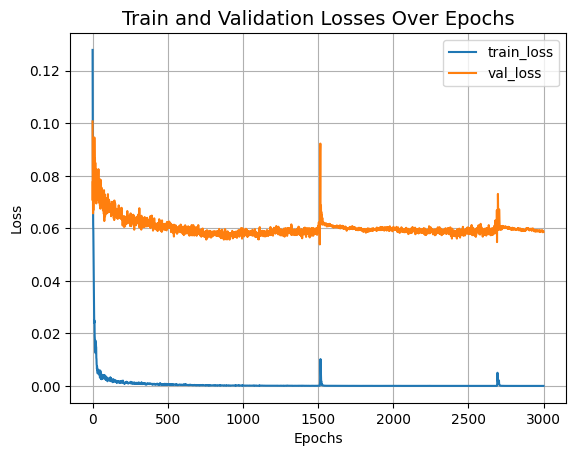

In [ ]:
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Train and Validation Losses Over Epochs", fontsize=14)
plt.legend()
plt.grid()
plt.show()

Let's display the final results of the training on CIFAR-100.

In [ ]:
results = model.evaluate(test_ds)

print("Evaluation results:", results)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.0849 - mae: 0.1215 
Evaluation results: [0.08493003249168396, 0.12151302397251129]


xb: (6, 299, 299, 1)
gt_bbox: (6, 4)
pred_bbox: (6, 4)


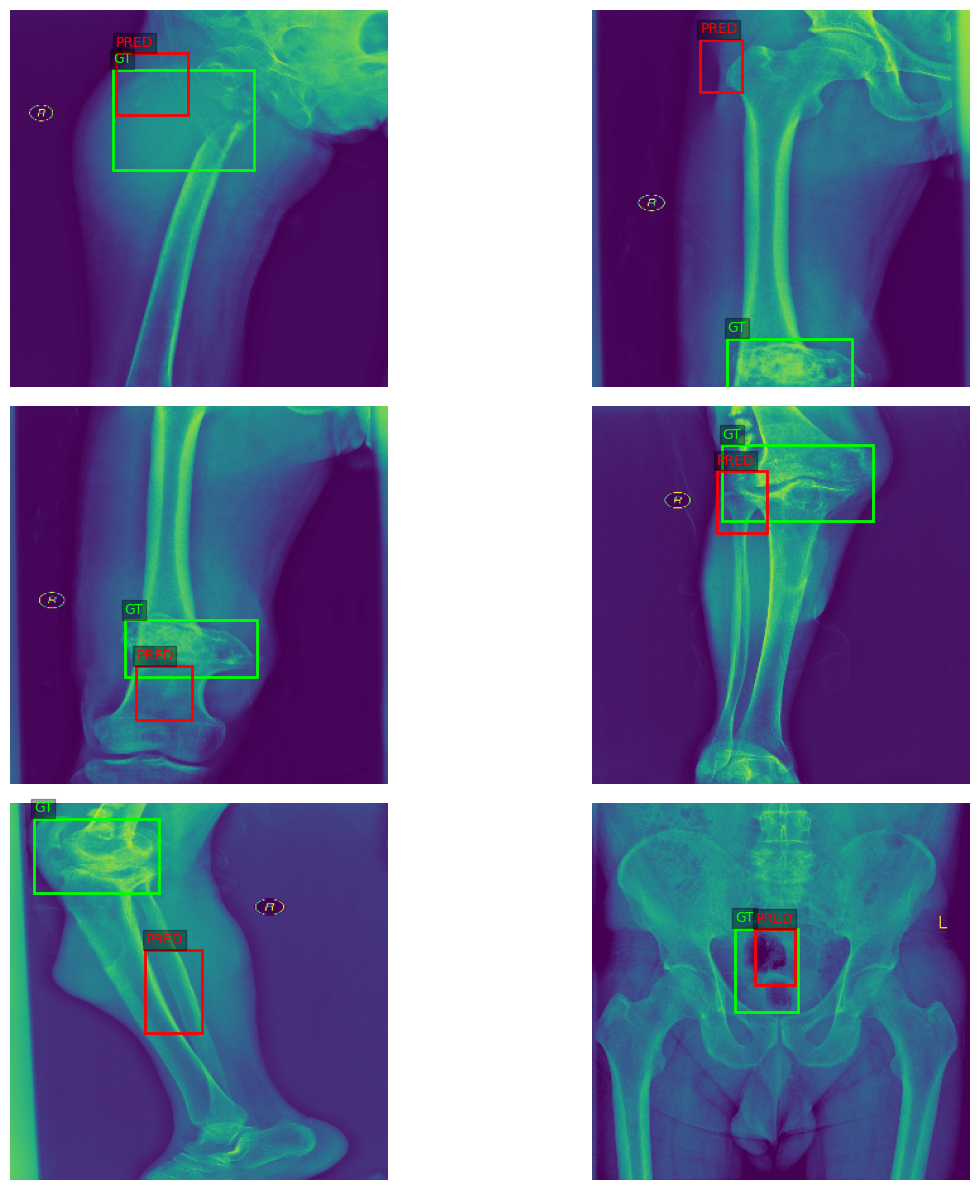

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def xywh_norm_to_pixels(box, img_w, img_h):
    x, y, w, h = box
    x1 = x * img_w
    y1 = y * img_h
    x2 = (x + w) * img_w
    y2 = (y + h) * img_h
    return x1, y1, x2, y2

def draw_box(ax, img, box, color, label):
    h, w = img.shape[:2]
    x1, y1, x2, y2 = xywh_norm_to_pixels(box, w, h)

    rect = patches.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        linewidth=2,
        edgecolor=color,
        facecolor="none"
    )
    ax.add_patch(rect)

    ax.text(
        x1,
        max(0, y1 - 5),
        label,
        color=color,
        fontsize=10,
        bbox=dict(facecolor="black", alpha=0.35, pad=2)
    )

# ------------------------------------------------------------
# Collect a few samples from test set
# ------------------------------------------------------------
num_samples = 6
selected_images = []
selected_boxes = []

for img, bbox in test_ds.unbatch().take(num_samples):
    selected_images.append(img)
    selected_boxes.append(bbox)

xb = tf.stack(selected_images)
gt_bbox = tf.stack(selected_boxes).numpy()

print("xb:", xb.shape)
print("gt_bbox:", gt_bbox.shape)

# ------------------------------------------------------------
# Predict
# ------------------------------------------------------------
pred = model.predict(xb, verbose=0)

if isinstance(pred, dict):
    pred_bbox = pred["bbox"]
else:
    pred_bbox = pred

pred_bbox = np.clip(pred_bbox, 0.0, 1.0)

print("pred_bbox:", pred_bbox.shape)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
N = xb.shape[0]
cols = 2
rows = int(np.ceil(N / cols))

plt.figure(figsize=(14, 4 * rows))

for i in range(N):
    ax = plt.subplot(rows, cols, i + 1)

    img = xb[i].numpy()
    img = np.clip(img, 0, 1)

    ax.imshow(img)
    ax.axis("off")

    draw_box(ax, img, gt_bbox[i], "lime", "GT")
    draw_box(ax, img, pred_bbox[i], "red", "PRED")

plt.tight_layout()
plt.show()

In [ ]:
def dynamic_bone_box_from_lesion(pred_box, margin=2.5):
    x, y, w, h = pred_box

    cx = x + w / 2
    cy = y + h / 2

    bone_w = w * margin
    bone_h = h * margin

    bone_x = cx - bone_w / 2
    bone_y = cy - bone_h / 2

    # clamp within image bounds
    bone_x = max(0.0, bone_x)
    bone_y = max(0.0, bone_y)
    bone_w = min(bone_w, 1.0 - bone_x)
    bone_h = min(bone_h, 1.0 - bone_y)

    return np.array([bone_x, bone_y, bone_w, bone_h], dtype=np.float32)

In [ ]:
def expand_box(box, factor=1.4):
    x, y, w, h = box

    cx = x + w / 2.0
    cy = y + h / 2.0

    new_w = w * factor
    new_h = h * factor

    new_x = cx - new_w / 2.0
    new_y = cy - new_h / 2.0

    # clamp within [0,1]
    new_x = max(0.0, new_x)
    new_y = max(0.0, new_y)
    new_w = min(new_w, 1.0 - new_x)
    new_h = min(new_h, 1.0 - new_y)

    return np.array([new_x, new_y, new_w, new_h], dtype=np.float32)

In [ ]:
def show_prediction(model, image_tensor, gt_box=None):
    xb = tf.expand_dims(image_tensor, axis=0)
    pred = model.predict(xb, verbose=0)

    pred_box = pred["bbox"][0] if isinstance(pred, dict) else pred[0]
    pred_box = np.clip(pred_box, 0, 1)
    pred_box = expand_box(pred_box, 1.4)

    bone_box = dynamic_bone_box_from_lesion(pred_box, margin=2.5)

    pred_sev = severity_percentage(pred_box, bone_box)
    pred_grade = severity_grade(pred_sev)

    img = np.clip(image_tensor.numpy(), 0, 1)

    plt.figure(figsize=(6, 6))
    ax = plt.gca()
    ax.imshow(img)
    ax.axis("off")

    draw_box(ax, img, bone_box, "cyan", "Bone ROI")
    draw_box(ax, img, pred_box, "red", f"PRED {pred_sev:.1f}%")

    if gt_box is not None:
        gt_box = np.array(gt_box, dtype=np.float32)
        gt_sev = severity_percentage(gt_box, bone_box)
        gt_grade = severity_grade(gt_sev)
        iou = compute_iou(pred_box, gt_box)

        draw_box(ax, img, gt_box, "lime", f"GT {gt_sev:.1f}%")

        plt.title(
            f"Pred: {pred_sev:.2f}% ({pred_grade}) | "
            f"GT: {gt_sev:.2f}% ({gt_grade}) | IoU: {iou:.3f}",
            fontsize=11
        )
    else:
        plt.title(
            f"Predicted Severity: {pred_sev:.2f}% | Level: {pred_grade}",
            fontsize=12
        )

    plt.show()

    print("Predicted lesion box:", pred_box.tolist())
    print("Dynamic bone box:", bone_box.tolist())
    print(f"Predicted severity percentage: {pred_sev:.2f}%")
    print(f"Predicted severity level: {pred_grade}")

In [ ]:
def severity_percentage(lesion_box, bone_box):
    x, y, w, h = lesion_box
    lesion_area = max(w, 0.0) * max(h, 0.0)

    x, y, w, h = bone_box
    bone_area = max(w, 0.0) * max(h, 0.0)

    if bone_area <= 0:
        return 0.0

    return (lesion_area / bone_area) * 100.0

In [ ]:
def severity_grade(p):
    if p < 10:
        return "Mild"
    elif p < 25:
        return "Moderate"
    elif p < 50:
        return "Severe"
    else:
        return "Very Severe"

In [ ]:
def compute_iou(boxA, boxB):
    xA, yA, wA, hA = boxA
    xB, yB, wB, hB = boxB

    xA2 = xA + wA
    yA2 = yA + hA
    xB2 = xB + wB
    yB2 = yB + hB

    # intersection
    xI1 = max(xA, xB)
    yI1 = max(yA, yB)
    xI2 = min(xA2, xB2)
    yI2 = min(yA2, yB2)

    inter_w = max(0.0, xI2 - xI1)
    inter_h = max(0.0, yI2 - yI1)
    intersection = inter_w * inter_h

    areaA = wA * hA
    areaB = wB * hB

    union = areaA + areaB - intersection

    if union <= 0:
        return 0.0

    return intersection / union

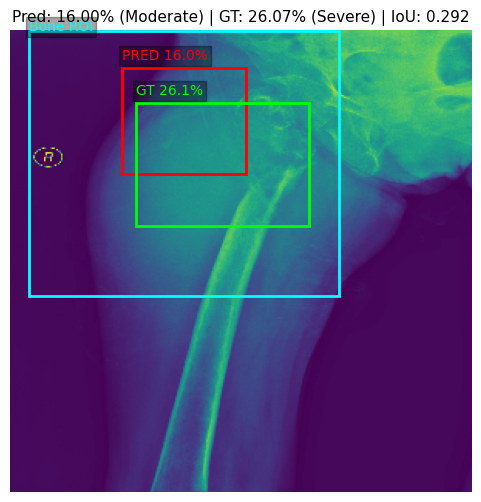

Predicted lesion box: [0.24070677161216736, 0.08023838698863983, 0.2681416869163513, 0.22927984595298767]
Dynamic bone box: [0.039600491523742676, 0.0, 0.6703542470932007, 0.5731996297836304]
Predicted severity percentage: 16.00%
Predicted severity level: Moderate


In [ ]:
img, gt_box = next(iter(test_ds.unbatch()))

show_prediction(
    model=model,
    image_tensor=img,
    gt_box=gt_box.numpy()
)

In [ ]:
def compute_mean_iou(model, dataset, num_samples=None):
    ious = []

    data = dataset.unbatch()
    if num_samples:
        data = data.take(num_samples)

    for img, gt_box in data:
        xb = tf.expand_dims(img, axis=0)
        pred = model.predict(xb, verbose=0)

        pred_box = pred["bbox"][0] if isinstance(pred, dict) else pred[0]
        pred_box = np.clip(pred_box, 0, 1)
        pred_box = expand_box(pred_box, 1.4)

        gt_box = np.array(gt_box.numpy(), dtype=np.float32)

        iou = compute_iou(pred_box, gt_box)
        ious.append(iou)

    mean_iou = np.mean(ious)
    median_iou = np.median(ious)

    print(f"Mean IoU   : {mean_iou:.4f}")
    print(f"Median IoU : {median_iou:.4f}")
    print(f"Total samples: {len(ious)}")

    return mean_iou, median_iou

In [ ]:
compute_mean_iou(
    model=model,
    dataset=test_ds,
    num_samples=50   # or None for full dataset
)

Mean IoU   : 0.1387
Median IoU : 0.0737
Total samples: 10


(np.float32(0.13871494), np.float32(0.073660105))

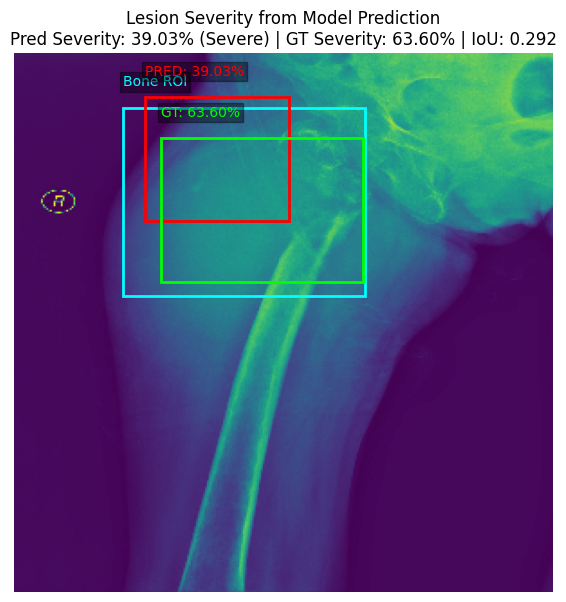

Expanded predicted lesion box: [0.24070677161216736, 0.08023838698863983, 0.2681416869163513, 0.22927984595298767]
Bone ROI box                : [0.20000000298023224, 0.10000000149011612, 0.44999998807907104, 0.3499999940395355]
Pred Severity               : 39.03%
Pred Grade                  : Severe
GT lesion box               : [0.27090319991111755, 0.15608465671539307, 0.3748856782913208, 0.26719576120376587]
GT Severity                 : 63.60%
IoU                         : 0.2917
{'index': 0, 'pred_box': [0.24070677161216736, 0.08023838698863983, 0.2681416869163513, 0.22927984595298767], 'gt_box': [0.27090319991111755, 0.15608465671539307, 0.3748856782913208, 0.26719576120376587], 'bone_box': [0.20000000298023224, 0.10000000149011612, 0.44999998807907104, 0.3499999940395355], 'pred_severity_pct': 39.03459513993327, 'gt_severity_pct': 63.598646688781244, 'pred_grade': 'Severe', 'gt_grade': 'Very Severe', 'iou': 0.2917468547821045}
{'index': 1, 'pred_box': [0.2637692391872406, 0.04

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def xywh_norm_to_pixels(box, img_w, img_h):
    x, y, w, h = box
    x1 = x * img_w
    y1 = y * img_h
    x2 = (x + w) * img_w
    y2 = (y + h) * img_h
    return x1, y1, x2, y2


def bbox_area_xywh(box):
    x, y, w, h = box
    return max(float(w), 0.0) * max(float(h), 0.0)


def severity_percentage(lesion_box, bone_box):
    lesion_area = bbox_area_xywh(lesion_box)
    bone_area = bbox_area_xywh(bone_box)

    if bone_area <= 0:
        return 0.0

    return (lesion_area / bone_area) * 100.0


def severity_grade(p):
    if p < 10:
        return "Mild"
    elif p < 25:
        return "Moderate"
    elif p < 50:
        return "Severe"
    else:
        return "Very Severe"


def expand_box(box, factor=1.4):
    """
    Expand normalized bbox [x, y, w, h] while keeping center fixed.
    """
    x, y, w, h = box

    cx = x + w / 2.0
    cy = y + h / 2.0

    new_w = w * factor
    new_h = h * factor

    new_x = cx - new_w / 2.0
    new_y = cy - new_h / 2.0

    # clamp to [0,1]
    new_x = max(0.0, new_x)
    new_y = max(0.0, new_y)
    new_w = min(new_w, 1.0 - new_x)
    new_h = min(new_h, 1.0 - new_y)

    return np.array([new_x, new_y, new_w, new_h], dtype=np.float32)


def compute_iou(boxA, boxB):
    """
    IoU for boxes in normalized [x, y, w, h] format.
    """
    xA1, yA1, wA, hA = boxA
    xA2 = xA1 + wA
    yA2 = yA1 + hA

    xB1, yB1, wB, hB = boxB
    xB2 = xB1 + wB
    yB2 = yB1 + hB

    # intersection
    xI1 = max(xA1, xB1)
    yI1 = max(yA1, yB1)
    xI2 = min(xA2, xB2)
    yI2 = min(yA2, yB2)

    inter_w = max(0.0, xI2 - xI1)
    inter_h = max(0.0, yI2 - yI1)
    intersection = inter_w * inter_h

    areaA = max(0.0, wA) * max(0.0, hA)
    areaB = max(0.0, wB) * max(0.0, hB)

    union = areaA + areaB - intersection

    if union <= 0:
        return 0.0

    return intersection / union


def draw_box(ax, img, box, color, label, linewidth=2):
    h, w = img.shape[:2]
    x1, y1, x2, y2 = xywh_norm_to_pixels(box, w, h)

    rect = patches.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        linewidth=linewidth,
        edgecolor=color,
        facecolor="none"
    )
    ax.add_patch(rect)

    ax.text(
        x1,
        max(0, y1 - 12),
        label,
        color=color,
        fontsize=10,
        bbox=dict(facecolor="black", alpha=0.4, pad=2)
    )


# ------------------------------------------------------------
# Show one image with model-predicted lesion, severity, and IoU
# bone_box is the reference bone ROI in normalized [x, y, w, h]
# gt_lesion_box is optional
# ------------------------------------------------------------
def show_prediction_with_severity_and_iou(
    model,
    image_tensor,
    bone_box,
    gt_lesion_box=None,
    expand_factor=1.4,
    title="Lesion Severity from Model Prediction"
):
    xb = tf.expand_dims(image_tensor, axis=0)

    pred = model.predict(xb, verbose=0)

    if isinstance(pred, dict):
        pred_box = pred["bbox"][0]
    else:
        pred_box = pred[0]

    pred_box = np.clip(np.array(pred_box, dtype=np.float32), 0.0, 1.0)
    pred_box = expand_box(pred_box, factor=expand_factor)

    bone_box = np.array(bone_box, dtype=np.float32)

    pred_severity = severity_percentage(pred_box, bone_box)
    pred_grade = severity_grade(pred_severity)

    img = image_tensor.numpy()
    img = np.clip(img, 0, 1)

    plt.figure(figsize=(7, 7))
    ax = plt.gca()
    ax.imshow(img)
    ax.axis("off")

    draw_box(ax, img, bone_box, "cyan", "Bone ROI", linewidth=2)
    draw_box(ax, img, pred_box, "red", f"PRED: {pred_severity:.2f}%")

    if gt_lesion_box is not None:
        gt_lesion_box = np.array(gt_lesion_box, dtype=np.float32)
        gt_severity = severity_percentage(gt_lesion_box, bone_box)
        iou = compute_iou(pred_box, gt_lesion_box)

        draw_box(ax, img, gt_lesion_box, "lime", f"GT: {gt_severity:.2f}%")

        ax.set_title(
            f"{title}\nPred Severity: {pred_severity:.2f}% ({pred_grade}) | "
            f"GT Severity: {gt_severity:.2f}% | IoU: {iou:.3f}",
            fontsize=12
        )
    else:
        iou = None
        ax.set_title(
            f"{title}\nPred Severity: {pred_severity:.2f}% ({pred_grade})",
            fontsize=12
        )

    plt.show()

    print("Expanded predicted lesion box:", pred_box.tolist())
    print("Bone ROI box                :", bone_box.tolist())
    print(f"Pred Severity               : {pred_severity:.2f}%")
    print(f"Pred Grade                  : {pred_grade}")

    if gt_lesion_box is not None:
        print("GT lesion box               :", gt_lesion_box.tolist())
        print(f"GT Severity                 : {gt_severity:.2f}%")
        print(f"IoU                         : {iou:.4f}")


# ------------------------------------------------------------
# Show multiple images with severity and IoU
# dataset should return (image, gt_lesion_box)
# bone_boxes must match image order
# ------------------------------------------------------------
def show_batch_prediction_with_severity_and_iou(
    model,
    dataset,
    bone_boxes,
    num_samples=6,
    expand_factor=1.4
):
    images = []
    gt_boxes = []

    for img, gt_box in dataset.unbatch().take(num_samples):
        images.append(img)
        gt_boxes.append(gt_box.numpy())

    if len(bone_boxes) < len(images):
        raise ValueError(f"Need at least {len(images)} bone ROI boxes, but got {len(bone_boxes)}.")

    cols = 2
    rows = int(np.ceil(len(images) / cols))
    plt.figure(figsize=(14, 4 * rows))

    for i, (img_t, gt_box, bone_box) in enumerate(zip(images, gt_boxes, bone_boxes), start=1):
        xb = tf.expand_dims(img_t, axis=0)
        pred = model.predict(xb, verbose=0)

        if isinstance(pred, dict):
            pred_box = pred["bbox"][0]
        else:
            pred_box = pred[0]

        pred_box = np.clip(np.array(pred_box, dtype=np.float32), 0.0, 1.0)
        pred_box = expand_box(pred_box, factor=expand_factor)

        bone_box = np.array(bone_box, dtype=np.float32)
        gt_box = np.array(gt_box, dtype=np.float32)

        pred_sev = severity_percentage(pred_box, bone_box)
        gt_sev = severity_percentage(gt_box, bone_box)
        iou = compute_iou(pred_box, gt_box)

        img = np.clip(img_t.numpy(), 0, 1)

        ax = plt.subplot(rows, cols, i)
        ax.imshow(img)
        ax.axis("off")

        draw_box(ax, img, bone_box, "cyan", "Bone ROI", linewidth=2)
        draw_box(ax, img, gt_box, "lime", f"GT: {gt_sev:.1f}%")
        draw_box(ax, img, pred_box, "red", f"PRED: {pred_sev:.1f}%")

        ax.set_title(f"Pred: {pred_sev:.2f}% | GT: {gt_sev:.2f}% | IoU: {iou:.3f}")

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Calculate severity and IoU for whole dataset
# returns per-image results + mean IoU
# ------------------------------------------------------------
def calculate_dataset_severity_and_iou(
    model,
    dataset,
    bone_boxes,
    num_samples=None,
    expand_factor=1.4
):
    results = []
    all_ious = []

    items = dataset.unbatch()
    if num_samples is not None:
        items = items.take(num_samples)

    for idx, (img_t, gt_box) in enumerate(items):
        if idx >= len(bone_boxes):
            raise ValueError(f"Missing bone ROI for sample index {idx}")

        xb = tf.expand_dims(img_t, axis=0)
        pred = model.predict(xb, verbose=0)

        if isinstance(pred, dict):
            pred_box = pred["bbox"][0]
        else:
            pred_box = pred[0]

        pred_box = np.clip(np.array(pred_box, dtype=np.float32), 0.0, 1.0)
        pred_box = expand_box(pred_box, factor=expand_factor)

        gt_box = np.array(gt_box.numpy(), dtype=np.float32)
        bone_box = np.array(bone_boxes[idx], dtype=np.float32)

        pred_sev = severity_percentage(pred_box, bone_box)
        gt_sev = severity_percentage(gt_box, bone_box)
        iou = compute_iou(pred_box, gt_box)
        all_ious.append(iou)

        results.append({
            "index": idx,
            "pred_box": pred_box.tolist(),
            "gt_box": gt_box.tolist(),
            "bone_box": bone_box.tolist(),
            "pred_severity_pct": float(pred_sev),
            "gt_severity_pct": float(gt_sev),
            "pred_grade": severity_grade(pred_sev),
            "gt_grade": severity_grade(gt_sev),
            "iou": float(iou),
        })

    mean_iou = float(np.mean(all_ious)) if len(all_ious) > 0 else 0.0
    median_iou = float(np.median(all_ious)) if len(all_ious) > 0 else 0.0

    return results, mean_iou, median_iou


# ------------------------------------------------------------
# EXAMPLE USAGE: single image
# ------------------------------------------------------------
img, gt_box = next(iter(test_ds.unbatch()))

# Replace with your actual bone ROI for this image
bone_box = [0.20, 0.10, 0.45, 0.35]

show_prediction_with_severity_and_iou(
    model=model,
    image_tensor=img,
    bone_box=bone_box,
    gt_lesion_box=gt_box.numpy(),
    expand_factor=1.4,
    title="Lesion Severity from Model Prediction"
)


# ------------------------------------------------------------
# EXAMPLE USAGE: multiple images
# You must provide one bone ROI per image in the same order
# ------------------------------------------------------------
bone_boxes = [
     [0.20, 0.10, 0.45, 0.35],
     [0.18, 0.55, 0.40, 0.25],
     [0.30, 0.60, 0.35, 0.15],
     [0.35, 0.18, 0.40, 0.22],
     [0.05, 0.02, 0.35, 0.20],
     [0.40, 0.42, 0.25, 0.20],
 ]
#
# show_batch_prediction_with_severity_and_iou(
#     model=model,
#     dataset=test_ds,
#     bone_boxes=bone_boxes,
#     num_samples=6,
#     expand_factor=1.4
# )


# ------------------------------------------------------------
# EXAMPLE USAGE: dataset-level metrics
# ------------------------------------------------------------
results, mean_iou, median_iou = calculate_dataset_severity_and_iou(
     model=model,
     dataset=test_ds,
     bone_boxes=bone_boxes,
    num_samples=6,
     expand_factor=1.4
 )

for r in results:
     print(r)

print("Mean IoU  :", mean_iou)
print("Median IoU:", median_iou)

## Relevant Chapters from Deep Learning with Python
- [Chapter 8: Image classification](https://deeplearningwithpython.io/chapters/chapter08_image-classification)
- [Chapter 15: Language models and the Transformer](https://deeplearningwithpython.io/chapters/chapter15_language-models-and-the-transformer)
